# MUNIC finance_push extraction — br-ibge / br-munic, release 2020-2021

Extracts the finance-push institutional capacity components from IBGE MUNIC 2020 (Meio ambiente, Gestão de riscos) and 2021 (Legislação e instrumentos de planejamento). Source and rules: see the review README one level up; raws in `sample/` with re-download URLs in the README. Output: one tidy table `data/br_munic_finance_push.csv`, one row per municipality.

In [1]:
# Parameters
RAW_2020 = "sample/Base_MUNIC_2020.xlsx"
RAW_2021 = "sample/Base_MUNIC_2021_20240425.xlsx"
OUT_CSV = "data/br_munic_finance_push.csv"
N_MUNICIPALITIES = 5570

import pandas as pd
pd.set_option("display.max_columns", 40)
print(f"target municipalities: {N_MUNICIPALITIES}")

target municipalities: 5570


## Load raw

Zero transformations at load. 2020 contributes two block sheets, 2021 one. No PII: MUNIC identifies gestor sex/age/race in some columns, which are never selected downstream.

In [2]:
# Load raw: 2020 environment block
raw_ma = pd.read_excel(RAW_2020, sheet_name="Meio ambiente", dtype=str)
raw_ma.shape

(5570, 113)

In [3]:
# Load raw: 2020 risk-and-disaster-management block
raw_gr = pd.read_excel(RAW_2020, sheet_name="Gestão de riscos", dtype=str)
raw_gr.shape

(5570, 166)

In [4]:
# Load raw: 2021 legislation-and-planning-instruments block
raw_lg = pd.read_excel(RAW_2021, sheet_name="Legislação e instr de planej", dtype=str)
raw_lg.shape

(5570, 54)

## Clean

One parsing note per block (see README, Parsing notes).

In [5]:
# Clean: drop trailing all-blank rows (parsing note: 2021 legislation sheet carries 7 trailing blank rows)
lg = raw_lg.dropna(how="all").copy()
ma = raw_ma.dropna(how="all").copy()
gr = raw_gr.dropna(how="all").copy()
{"2020_ma": len(ma), "2020_gr": len(gr), "2021_lg": len(lg), "blank_rows_dropped_2021": len(raw_lg) - len(lg)}

{'2020_ma': 5570,
 '2020_gr': 5570,
 '2021_lg': 5570,
 'blank_rows_dropped_2021': 0}

In [6]:
# Clean: municipality code to 7-character string key (parsing note: CodMun is an identifier, not a number)
for df in (ma, gr, lg):
    df["cod_mun"] = df["CodMun"].str.strip().str.zfill(7)
ma[["CodMun", "cod_mun"]].head(3)

,CodMun,cod_mun
0,1100015,1100015
1,1100023,1100023
2,1100031,1100031


In [7]:
# Clean: map the response vocabulary to explicit statuses (parsing note: Sim/Não/Recusa/Não informou/"-" must stay distinct)
YES, NO, UNKNOWN, SKIP = "yes", "no", "unknown", "__skip__"
VOCAB = {
    "Sim": YES,
    "Não": NO,
    "Recusa": UNKNOWN,            # whole-survey refusal (90 municipalities in 2020)
    "Não informou": UNKNOWN,
    "Não soube informar": UNKNOWN,
    "-": SKIP,                    # skip logic; resolved per component below
}
def status(series):
    out = series.str.strip().map(VOCAB)
    if out.isna().any():
        unmapped = sorted(series[out.isna()].unique())
        raise ValueError(f"unmapped values: {unmapped}")
    return out
status(ma["Mmam10"]).value_counts()

Mmam10
yes        4375
no         1093
unknown     102
Name: count, dtype: int64

## Derive the finance_push components

One block per component. Each component is a categorical status column; skip logic (`-`) resolves to a named state, never silently to `no`.

In [8]:
# Component: environment governance body (Mmam01, 2020)
BODY_MAP = {
    "Secretaria exclusiva": "dedicated",
    "Órgão da administração indireta": "dedicated",
    "Secretaria em conjunto com outras políticas setoriais": "shared",
    "Setor subordinado a outra secretaria": "shared",
    "Setor subordinado diretamente à chefia do Executivo": "shared",
    "Não possui estrutura": "none",
    "Recusa": UNKNOWN,
    "Não informou": UNKNOWN,
}
comp = ma[["cod_mun"]].copy()
comp["env_body_status"] = ma["Mmam01"].str.strip().map(BODY_MAP)
assert comp["env_body_status"].notna().all()
comp["env_body_status"].value_counts()

env_body_status
shared       3522
dedicated    1658
none          288
unknown       102
Name: count, dtype: int64

In [9]:
# Component: environment council, and whether it has its own budget line (Mmam10, Mmam15/Mmam1518, 2020)
comp["env_council_status"] = status(ma["Mmam10"])
budget = status(ma["Mmam1518"].replace("Não foi instalado ou está inativo", "Não"))
inactive = ma["Mmam15"].str.strip().eq("Não foi instalado ou está inativo")
no_council = comp["env_council_status"].ne(YES)
comp["env_council_budget_status"] = budget.mask(inactive, "council_inactive")
comp.loc[comp["env_council_budget_status"].eq(SKIP) & no_council, "env_council_budget_status"] = "no_council"
comp.loc[comp["env_council_budget_status"].eq(SKIP), "env_council_budget_status"] = NO  # council exists, no infrastructure provided
comp["env_council_budget_status"].value_counts()

env_council_budget_status
no                  3844
no_council          1093
yes                  366
council_inactive     164
unknown              103
Name: count, dtype: int64

In [10]:
# Component: environment fund, and whether it was used the year before the survey (Mmam17, Mmam18, 2020)
comp["env_fund_status"] = status(ma["Mmam17"])
used = status(ma["Mmam18"])
comp["env_fund_used_status"] = used.mask(used.eq(SKIP), "no_fund")
comp["env_resources_status"] = status(ma["Mmam16"])  # area has earmarked resources for its actions
comp[["env_fund_status", "env_fund_used_status", "env_resources_status"]].apply(lambda s: s.value_counts()).fillna(0).astype(int)

,env_fund_status,env_fund_used_status,env_resources_status
no,2193,1804,2883
no_fund,0,2193,0
unknown,103,106,109
yes,3274,1467,2578


In [11]:
# Component: climate adaptation/mitigation legislation (Mmam2011 + year, 2020)
comp["climate_legislation_status"] = status(ma["Mmam2011"])
year = pd.to_numeric(ma["Mmam20111"].replace({"-": None, "Recusa": None, "Não informou": None, "Não soube informar": None}), errors="coerce")
comp["climate_legislation_year"] = year.astype("Int64")
comp["climate_legislation_status"].value_counts()

climate_legislation_status
no         5070
yes         390
unknown     110
Name: count, dtype: int64

In [12]:
# Component: federal climate training for municipal staff (Mmam08 root, Mmam098 topic, 2020)
# Skip logic verified: Mmam098 "-" occurs exactly where Mmam08 = Não (no federal environment training at all).
root = status(ma["Mmam08"])
topic = status(ma["Mmam098"])
comp["climate_training_status"] = topic.mask(topic.eq(SKIP), "no_env_training").mask(root.eq(YES) & topic.eq(NO), "env_training_other_topics")
comp["climate_training_status"].value_counts()

climate_training_status
no_env_training              3496
env_training_other_topics    1778
yes                           193
unknown                       103
Name: count, dtype: int64

In [13]:
# Component: civil-defence structure and its finance readiness (Mgrd212/225/226/2212, 2020)
# Skip logic verified: the Mgrd22* battery is asked only where a COMPDEC or similar exists (Mgrd212 = Sim).
gr_i = gr.set_index("cod_mun")
body = status(gr_i["Mgrd212"])
def compdec_conditional(col):
    s = status(gr_i[col])
    return s.mask(s.eq(SKIP), "no_body")
cd = pd.DataFrame({
    "civil_defence_body_status": body,
    "civil_defence_budget_status": compdec_conditional("Mgrd225"),   # civil-defence line in the annual budget law
    "civil_defence_other_funding_status": compdec_conditional("Mgrd226"),
    "civil_defence_staff_status": compdec_conditional("Mgrd2212"),
}).reset_index()
comp = comp.merge(cd, on="cod_mun", validate="1:1")
comp["civil_defence_budget_status"].value_counts()

civil_defence_budget_status
no         3265
no_body    1229
yes         968
unknown     108
Name: count, dtype: int64

In [14]:
# Component: planning instruments (Mleg01 plano diretor + 21-instrument battery, 2021)
INSTRUMENT_VARS = [f"Mleg{i:02d}" for i in range(2, 23)]  # Mleg02..Mleg22, existence only
lg_i = lg.set_index("cod_mun")
pd_status = status(lg_i["Mleg01"])
pd_year = pd.to_numeric(lg_i["Mleg011"].replace({"-": None, "Recusa": None, "Não informou": None, "Não soube informar": None}), errors="coerce")
inst = lg_i[INSTRUMENT_VARS].apply(lambda s: status(s.str.strip().str.replace(r"^Sim,.*", "Sim", regex=True)))  # parsing note: some instruments answer "Sim, com legislação específica" / "Sim, como parte integrante do Plano Diretor"
count = inst.eq(YES).sum(axis=1)
count = count.mask(inst.eq(UNKNOWN).all(axis=1))  # whole-block refusals get no count, not zero
pl = pd.DataFrame({
    "plano_diretor_status": pd_status,
    "plano_diretor_year": pd_year.astype("Int64"),
    "planning_instrument_count": count.astype("Int64"),
}).reset_index()
comp = comp.merge(pl, on="cod_mun", validate="1:1")
comp["planning_instrument_count"].describe()

count       5562.0
mean     10.272204
std       6.431131
min            0.0
25%            5.0
50%           10.0
75%           16.0
max           21.0
Name: planning_instrument_count, dtype: Float64

In [15]:
# Identity columns and the 2020 whole-survey refusal flag
ident = ma.set_index("cod_mun")[["Mun", "UF", "Regiao", "Faixa_pop"]].rename(
    columns={"Mun": "mun_name", "UF": "uf", "Regiao": "region", "Faixa_pop": "pop_band"})
ident["region"] = ident["region"].str.split(" - ").str[-1]
comp = comp.merge(ident.reset_index(), on="cod_mun", validate="1:1")
comp["is_survey_refusal_2020"] = ma.set_index("cod_mun")["Mmam01"].str.strip().eq("Recusa").reindex(comp["cod_mun"]).to_numpy()
ID_COLS = ["cod_mun", "mun_name", "uf", "region", "pop_band", "is_survey_refusal_2020"]
comp = comp[ID_COLS + [c for c in comp.columns if c not in ID_COLS]]
comp.head(3)

,cod_mun,mun_name,uf,region,pop_band,is_survey_refusal_2020,env_body_status,env_council_status,env_council_budget_status,env_fund_status,env_fund_used_status,env_resources_status,climate_legislation_status,climate_legislation_year,climate_training_status,civil_defence_body_status,civil_defence_budget_status,civil_defence_other_funding_status,civil_defence_staff_status,plano_diretor_status,plano_diretor_year,planning_instrument_count
0,1100015,Alta Floresta DOeste,RO,Norte,4 - 20001 até 50000,False,shared,yes,no,yes,no,yes,no,<NA>,no_env_training,no,no_body,no_body,no_body,yes,2006,13
1,1100023,Ariquemes,RO,Norte,6 - 100001 até 500000,False,dedicated,yes,yes,yes,yes,yes,no,<NA>,no_env_training,yes,no,no,yes,yes,2019,20
2,1100031,Cabixi,RO,Norte,2 - 5001 até 10000,False,shared,no,no_council,no,no_fund,no,no,<NA>,no_env_training,no,no_body,no_body,no_body,no,<NA>,6


## Validate

Assertions, not eyeballing. Counts are pinned to the profiling pass recorded in the README; known source-side facts are asserted as named exceptions.

In [16]:
# Validate: shape, key, and pinned national counts
assert len(comp) == N_MUNICIPALITIES, len(comp)
assert comp["cod_mun"].is_unique
assert comp["cod_mun"].str.fullmatch(r"\d{7}").all()
assert comp.notna().sum().min() > 0

pinned = {
    ("env_council_status", "yes"): 4375,
    ("env_fund_status", "yes"): 3274,
    ("env_fund_used_status", "yes"): 1467,
    ("climate_legislation_status", "yes"): 390,
    ("climate_training_status", "yes"): 193,
    ("civil_defence_body_status", "yes"): 4236,
    ("civil_defence_budget_status", "yes"): 968,
    ("plano_diretor_status", "yes"): 2960,
}
for (col, val), expected in pinned.items():
    got = int(comp[col].eq(val).sum())
    assert got == expected, (col, val, got, expected)

# Named exception: 90 municipalities refused the whole 2020 survey; their 2020 components are unknown, never "no".
assert int(comp["is_survey_refusal_2020"].sum()) == 90
refused = comp[comp["is_survey_refusal_2020"]]
for col in ["env_body_status", "env_council_status", "env_fund_status", "climate_legislation_status", "civil_defence_body_status"]:
    assert refused[col].eq("unknown").all(), col

# Legislation years within a plausible range where present
yrs = comp["climate_legislation_year"].dropna()
assert yrs.between(1980, 2021).all()

# No skip sentinel survives into the output
assert not comp.isin(["__skip__"]).any().any()
print("all validations passed")

all validations passed


## Export

One committed, pipeline-ready table.

In [17]:
# Export: tidy component table
import os
os.makedirs("data", exist_ok=True)
comp.to_csv(OUT_CSV, index=False)
print(OUT_CSV, comp.shape)

data/br_munic_finance_push.csv (5570, 22)


## Visualise and fit

The aggregates the review cites, rendered inline only. Fit cells answer the finance-push questions the originating method raises, nothing more.

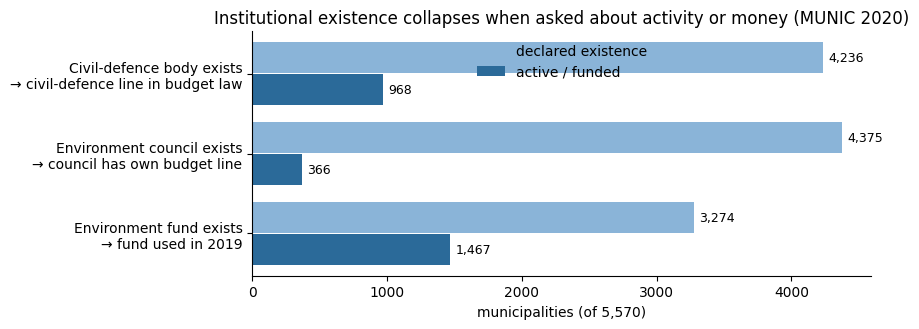

In [18]:
# Chart: declared existence vs observed activity (the collapse the README warns about)
import matplotlib.pyplot as plt
pairs = [
    ("Environment fund exists", comp["env_fund_status"].eq("yes").sum(), "fund used in 2019", comp["env_fund_used_status"].eq("yes").sum()),
    ("Environment council exists", comp["env_council_status"].eq("yes").sum(), "council has own budget line", comp["env_council_budget_status"].eq("yes").sum()),
    ("Civil-defence body exists", comp["civil_defence_body_status"].eq("yes").sum(), "civil-defence line in budget law", comp["civil_defence_budget_status"].eq("yes").sum()),
]
fig, ax = plt.subplots(figsize=(9, 3.4))
ypos = range(len(pairs))
ax.barh([y + 0.2 for y in ypos], [p[1] for p in pairs], height=0.38, color="#8ab4d8", label="declared existence")
ax.barh([y - 0.2 for y in ypos], [p[3] for p in pairs], height=0.38, color="#2b6a99", label="active / funded")
ax.set_yticks(list(ypos), [f"{p[0]}\n→ {p[2]}" for p in pairs])
for y, p in zip(ypos, pairs):
    ax.text(p[1] + 40, y + 0.2, f"{p[1]:,}", va="center", fontsize=9)
    ax.text(p[3] + 40, y - 0.2, f"{p[3]:,}", va="center", fontsize=9)
ax.set_xlabel("municipalities (of 5,570)")
ax.set_title("Institutional existence collapses when asked about activity or money (MUNIC 2020)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

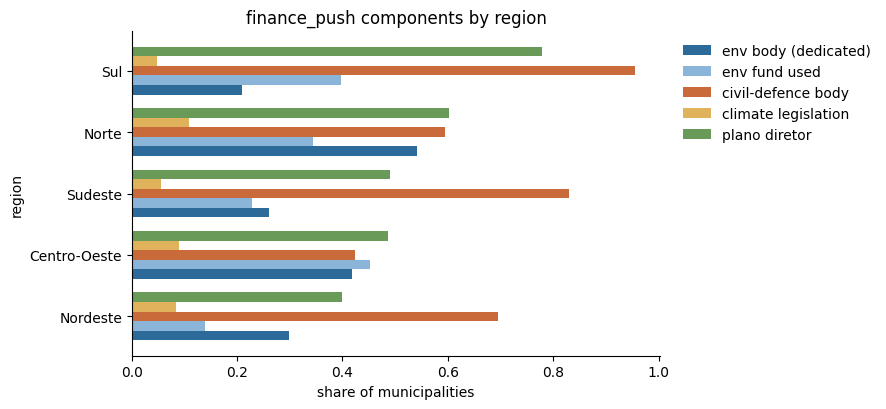

,env body (dedicated),env fund used,civil-defence body,climate legislation,plano diretor
region,,,,,
Centro-Oeste,0.418,0.452,0.424,0.090,0.486
Nordeste,0.299,0.139,0.695,0.084,0.399
Norte,0.542,0.344,0.596,0.109,0.602
Sudeste,0.260,0.228,0.830,0.056,0.490
Sul,0.210,0.396,0.955,0.047,0.779


In [19]:
# Chart: component yes-share by region
key_components = {
    "env body (dedicated)": comp["env_body_status"].eq("dedicated"),
    "env fund used": comp["env_fund_used_status"].eq("yes"),
    "civil-defence body": comp["civil_defence_body_status"].eq("yes"),
    "climate legislation": comp["climate_legislation_status"].eq("yes"),
    "plano diretor": comp["plano_diretor_status"].eq("yes"),
}
by_region = pd.DataFrame({name: flag.groupby(comp["region"]).mean() for name, flag in key_components.items()})
ax = by_region.sort_values("plano diretor").plot.barh(figsize=(9, 4.2), width=0.78,
    color=["#2b6a99", "#8ab4d8", "#c96a3b", "#e0b25c", "#6a9a58"])
ax.set_xlabel("share of municipalities")
ax.set_title("finance_push components by region")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
by_region.round(3)

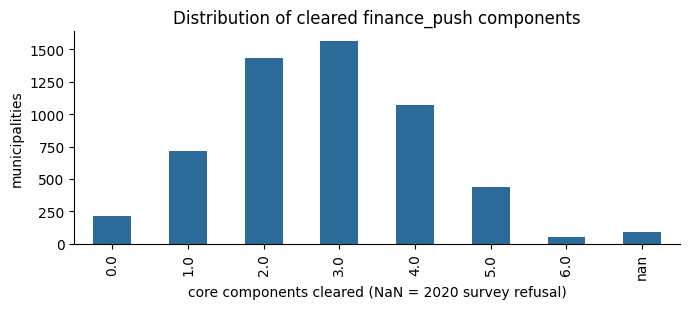

0.0     210
1.0     715
2.0    1435
3.0    1562
4.0    1070
5.0     434
6.0      54
NaN      90
Name: count, dtype: int64

In [20]:
# Fit: how many of the six core components does each municipality clear?
core = pd.DataFrame({
    "env_body": comp["env_body_status"].eq("dedicated"),
    "env_council": comp["env_council_status"].eq("yes"),
    "env_fund_used": comp["env_fund_used_status"].eq("yes"),
    "civil_defence": comp["civil_defence_body_status"].eq("yes"),
    "climate_legislation": comp["climate_legislation_status"].eq("yes"),
    "plano_diretor": comp["plano_diretor_status"].eq("yes"),
})
n_pass = core.sum(axis=1).mask(comp["is_survey_refusal_2020"])
dist = n_pass.value_counts(dropna=False).sort_index()
ax = dist.plot.bar(figsize=(7, 3.2), color="#2b6a99")
ax.set_xlabel("core components cleared (NaN = 2020 survey refusal)")
ax.set_ylabel("municipalities")
ax.set_title("Distribution of cleared finance_push components")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
dist

In [21]:
# Fit: does the climate-specific signal follow city size? (share with climate legislation by population band)
band = comp.loc[~comp["is_survey_refusal_2020"]].copy()
share = band.groupby("pop_band")["climate_legislation_status"].apply(lambda s: s.eq("yes").mean())
share.round(3).to_frame("share_with_climate_legislation")

,share_with_climate_legislation
pop_band,
1 - Até 5000,0.037
2 - 5001 até 10000,0.043
3 - 10001 até 20000,0.069
4 - 20001 até 50000,0.097
5 - 50001 até 100000,0.104
6 - 100001 até 500000,0.159
7 - Maior que 500000,0.375


## Findings

Extraction confirmed the profiled counts exactly and surfaced nothing new that contradicts the README. Three facts worth carrying: the existence-to-activity collapse is large and consistent (fund 3,274 → used 1,467; council 4,375 → own budget line 366; civil-defence body 4,236 → budget-law line 968), so the method should score activity, not declarations; climate-specific signals are rare and size-graded (390 municipalities with climate legislation, 193 with climate-trained staff, concentrated in larger population bands); and the skip-logic filters resolved cleanly (`Mmam098` hangs off the training question `Mmam08`; the `Mgrd22*` battery hangs off COMPDEC existence), which the status vocabulary makes explicit instead of collapsing to "no". All of this is reflected in the README's interpretation warnings and the release review.md.